### Breast Cancer Classification Using Machine Learning

### Project Overview

This project explores the Breast Cancer Wisconsin dataset available through scikit-learn and develops machine-learning models to classify tumors as malignant or benign.

The analysis includes exploratory data analysis, model development, cross-validation, hyperparameter tuning, and evaluation on an untouched test dataset.

### Objectives
- Explore characteristics associated with malignant and benign tumors
- Identify relationships among tumor features
- Compare multiple classification algorithms
- Evaluate model generalization using cross-validation
- Select and evaluate a final classification model

### Machine Learning Models
- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

### Tools
Pandas | Matplotlib | Seaborn | Scikit-learn


## 1. Import Libraries


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)


#### 2. Dataset

The Breast Cancer Wisconsin dataset contains measurements derived from digitized images of breast mass cell nuclei.

The target variable contains two classes:
- 0 — Malignant
- 1 — Benign

The dataset contains 569 observations and 30 numerical predictor variables.


In [27]:
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["Target"] = cancer.target
df["Diagnosis"] = df["Target"].map({0: "Malignant", 1: "Benign"})

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


#### 3. Initial Data Exploration


In [28]:
print("Dataset shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nDiagnosis counts:")
print(df["Diagnosis"].value_counts())


Dataset shape: (569, 32)

Missing values: 0

Diagnosis counts:
Diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


#### 4. Exploratory Data Analysis

Exploratory analysis was used to examine class balance, feature distributions, relationships between tumor measurements, and correlations among selected predictors.


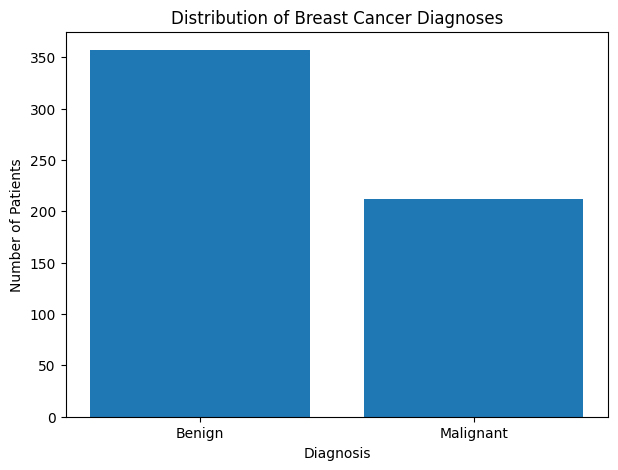

In [29]:
diagnosis_counts = df["Target"].value_counts()
labels = ["Benign", "Malignant"]

plt.figure(figsize=(7, 5))
plt.bar(labels, diagnosis_counts.values)

plt.title("Distribution of Breast Cancer Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.show()

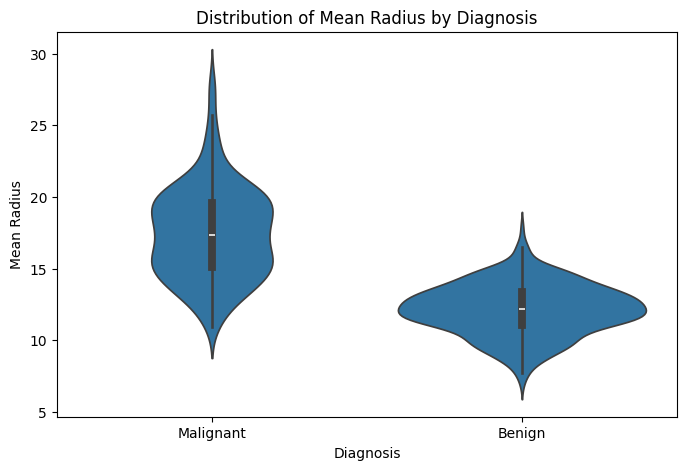

In [30]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Diagnosis",
    y="mean radius"
)

plt.title("Distribution of Mean Radius by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Radius")

plt.show()

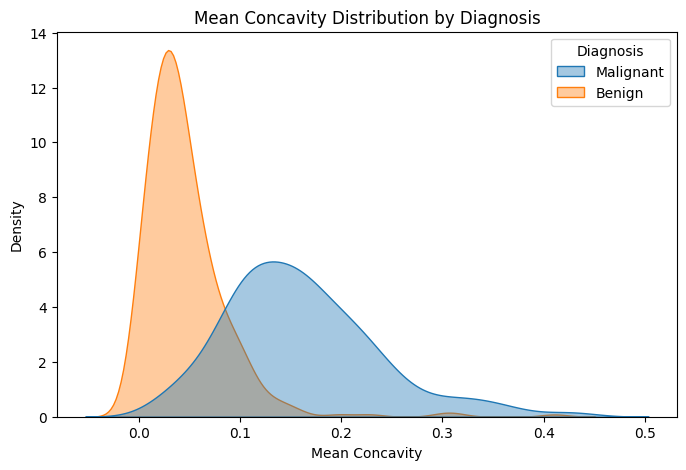

In [31]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x="mean concavity",
    hue="Diagnosis",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("Mean Concavity Distribution by Diagnosis")
plt.xlabel("Mean Concavity")
plt.ylabel("Density")

plt.show()

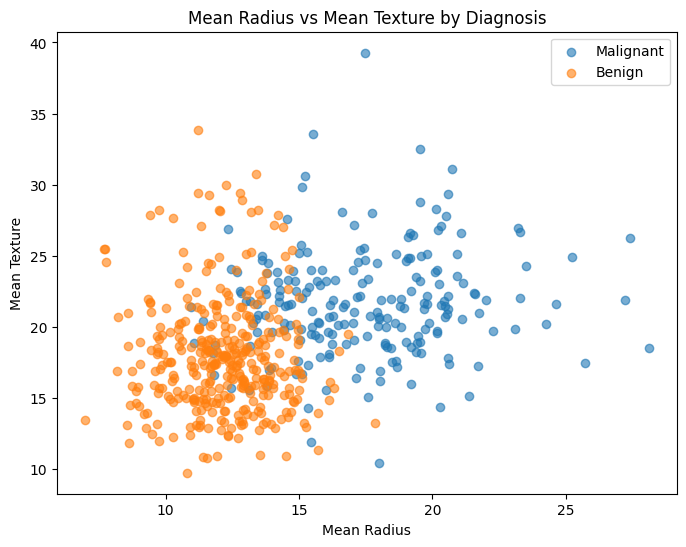

In [32]:
plt.figure(figsize=(8, 6))

malignant = df[df["Target"] == 0]
benign = df[df["Target"] == 1]

plt.scatter(
    malignant["mean radius"],
    malignant["mean texture"],
    label="Malignant",
    alpha=0.6
)

plt.scatter(
    benign["mean radius"],
    benign["mean texture"],
    label="Benign",
    alpha=0.6
)

plt.title("Mean Radius vs Mean Texture by Diagnosis")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")

plt.legend()

plt.show()

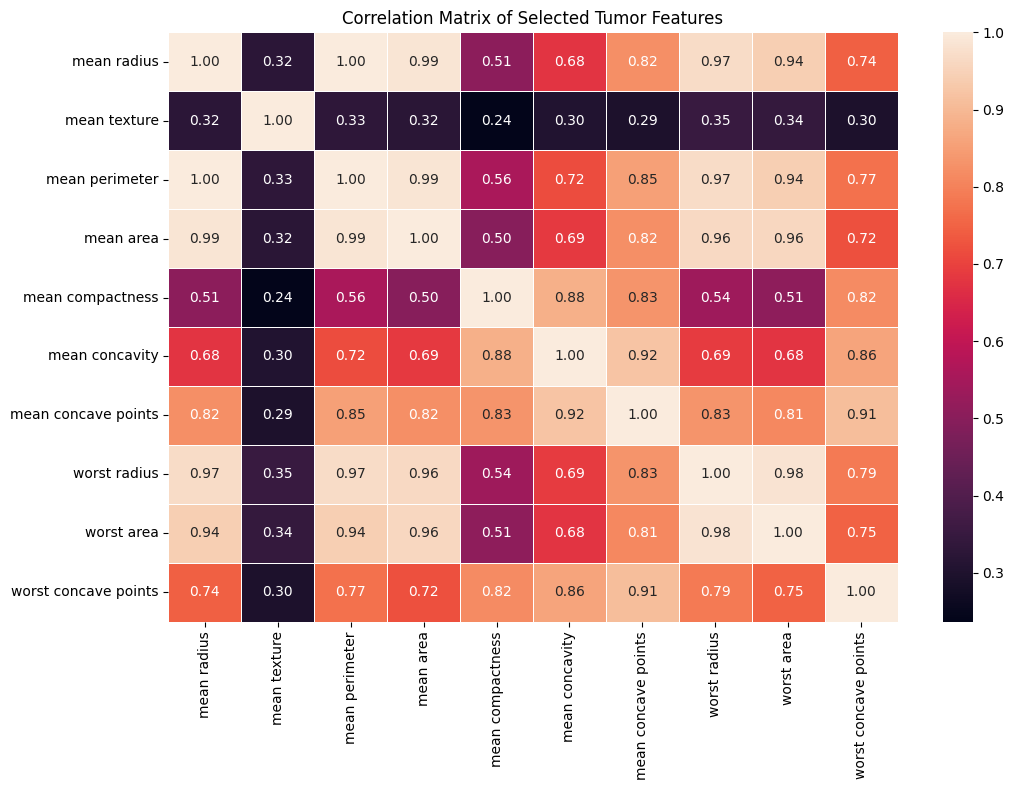

In [33]:
features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "worst radius",
    "worst area",
    "worst concave points"
]

corr = df[features].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Selected Tumor Features")

plt.tight_layout()
plt.show()

#### EDA Findings

The exploratory analysis indicates visible differences between malignant and benign observations across several tumor measurements. Radius- and concavity-related variables show particularly strong separation between the two diagnosis groups.

Several predictors are also highly correlated, especially radius, perimeter, and area-related measurements. These relationships suggest substantial shared information among tumor-size variables.


#### 5. Data Preparation

The predictor variables were separated from the target variable. The data were then divided into training, validation, and test sets using a **70% / 15% / 15% split**.

Stratified sampling was used to preserve the proportion of malignant and benign observations across the three subsets.

The test set was kept separate from model development and used only for final evaluation.


In [34]:
X = df.drop(columns=["Target", "Diagnosis"])
y = df["Target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (398, 30)
Validation set: (85, 30)
Test set: (86, 30)


In [35]:
split_distribution = pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Training": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
})

split_distribution.index = ["Malignant", "Benign"]
(split_distribution * 100).round(2)


,Original,Training,Validation,Test
Malignant,62.74,62.81,62.35,62.79
Benign,37.26,37.19,37.65,37.21


#### 6. Feature Scaling

Standardization was applied to Logistic Regression and SVM because these algorithms are sensitive to differences in feature scale.

The scaler was fitted using only the training data to prevent information leakage. Random Forest was trained using the original feature values because tree-based models do not require feature standardization.


In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


#### 7. Model Development

Three classification algorithms were evaluated:
1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)

Each model was trained using the training set and initially evaluated using the validation set.


#### 7.1 Logistic Regression


In [37]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_train_pred = log_model.predict(X_train_scaled)
log_val_pred = log_model.predict(X_val_scaled)

print(f"Training Accuracy: {accuracy_score(y_train, log_train_pred):.2%}")
print(f"Validation Accuracy: {accuracy_score(y_val, log_val_pred):.2%}")
print()
print(classification_report(
    y_val, log_val_pred,
    target_names=["Malignant", "Benign"]
))


Training Accuracy: 98.74%
Validation Accuracy: 98.82%

              precision    recall  f1-score   support

   Malignant       0.97      1.00      0.98        32
      Benign       1.00      0.98      0.99        53

    accuracy                           0.99        85
   macro avg       0.98      0.99      0.99        85
weighted avg       0.99      0.99      0.99        85



#### 7.2 Random Forest


In [38]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)

print(f"Training Accuracy: {accuracy_score(y_train, rf_train_pred):.2%}")
print(f"Validation Accuracy: {accuracy_score(y_val, rf_val_pred):.2%}")
print()
print(classification_report(
    y_val, rf_val_pred,
    target_names=["Malignant", "Benign"]
))


Training Accuracy: 100.00%
Validation Accuracy: 98.82%

              precision    recall  f1-score   support

   Malignant       0.97      1.00      0.98        32
      Benign       1.00      0.98      0.99        53

    accuracy                           0.99        85
   macro avg       0.98      0.99      0.99        85
weighted avg       0.99      0.99      0.99        85



Random Forest achieved perfect training accuracy and strong validation performance. Cross-validation was therefore used later to examine whether its performance remained stable across different subsets of the training data.


#### 7.3 Support Vector Machine


In [39]:
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_train_pred = svm_model.predict(X_train_scaled)
svm_val_pred = svm_model.predict(X_val_scaled)

print(f"Training Accuracy: {accuracy_score(y_train, svm_train_pred):.2%}")
print(f"Validation Accuracy: {accuracy_score(y_val, svm_val_pred):.2%}")
print()
print(classification_report(
    y_val, svm_val_pred,
    target_names=["Malignant", "Benign"]
))


Training Accuracy: 98.24%
Validation Accuracy: 97.65%

              precision    recall  f1-score   support

   Malignant       0.94      1.00      0.97        32
      Benign       1.00      0.96      0.98        53

    accuracy                           0.98        85
   macro avg       0.97      0.98      0.98        85
weighted avg       0.98      0.98      0.98        85



#### 8. Validation Performance Comparison

The models were compared using accuracy, malignant-class precision, recall, F1-score, and ROC-AUC. Because malignant tumors are encoded as class 0, malignant-class metrics were calculated explicitly using *pos_label=0*.


In [40]:
log_val_prob = log_model.predict_proba(X_val_scaled)[:, 0]
rf_val_prob = rf_model.predict_proba(X_val)[:, 0]
svm_val_prob = svm_model.predict_proba(X_val_scaled)[:, 0]

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=0),
        "Recall": recall_score(y_true, y_pred, pos_label=0),
        "F1 Score": f1_score(y_true, y_pred, pos_label=0),
        "ROC-AUC": roc_auc_score((y_true == 0).astype(int), y_prob)
    }

results = [
    evaluate_model("Logistic Regression", y_val, log_val_pred, log_val_prob),
    evaluate_model("Random Forest", y_val, rf_val_pred, rf_val_prob),
    evaluate_model("SVM", y_val, svm_val_pred, svm_val_prob)
]

results_df = pd.DataFrame(results)
results_df.round(3)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.988,0.970,1.0,0.985,1.000
1,Random Forest,0.988,0.970,1.0,0.985,0.999
2,SVM,0.976,0.941,1.0,0.970,1.000


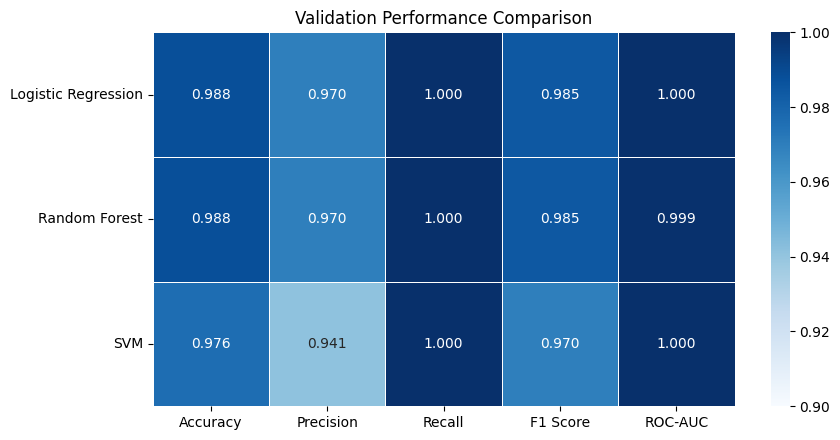

In [41]:
comparison = results_df.set_index("Model")

plt.figure(figsize=(9, 4.5))
sns.heatmap(
    comparison,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    vmin=0.90,
    vmax=1.00
)

plt.title("Validation Performance Comparison")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Validation Findings

Logistic Regression and Random Forest achieved the highest validation accuracy at **98.82%**, while SVM achieved **97.65%**.

Because performance from a single validation split can vary, five-fold cross-validation was used next to assess model stability across multiple training subsets.


#### 9. Cross-Validation


In [42]:
log_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

rf_cv_model = RandomForestClassifier(n_estimators=100, random_state=42)

svm_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

log_cv_scores = cross_val_score(log_cv_model, X_train, y_train, cv=5, scoring="accuracy")
rf_cv_scores = cross_val_score(rf_cv_model, X_train, y_train, cv=5, scoring="accuracy")
svm_cv_scores = cross_val_score(svm_cv_model, X_train, y_train, cv=5, scoring="accuracy")

cv_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Mean CV Accuracy": [
        log_cv_scores.mean(),
        rf_cv_scores.mean(),
        svm_cv_scores.mean()
    ],
    "Standard Deviation": [
        log_cv_scores.std(),
        rf_cv_scores.std(),
        svm_cv_scores.std()
    ]
})

cv_summary.round(4)


,Model,Mean CV Accuracy,Standard Deviation
0,Logistic Regression,0.9799,0.0150
1,Random Forest,0.9725,0.0330
2,SVM,0.9698,0.0129


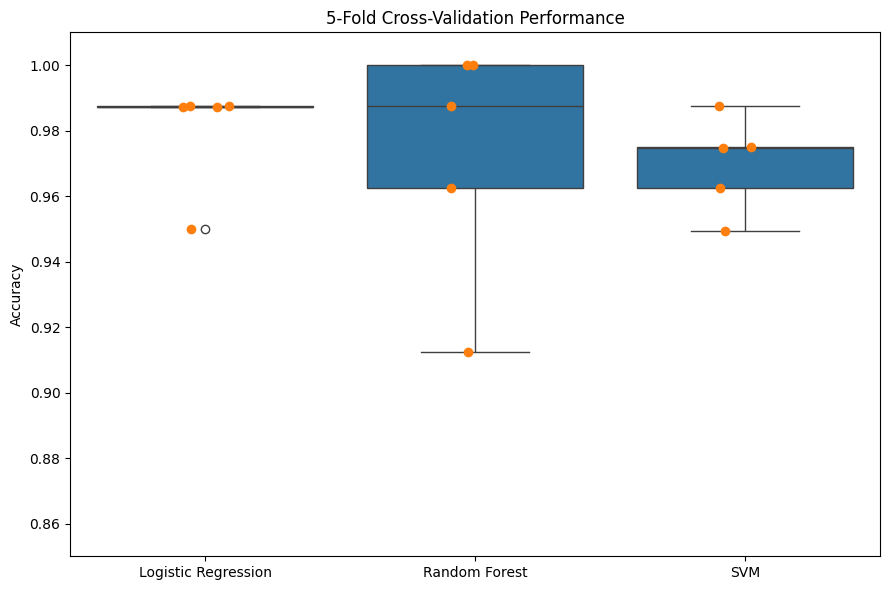

In [43]:
cv_results = pd.DataFrame({
    "Logistic Regression": log_cv_scores,
    "Random Forest": rf_cv_scores,
    "SVM": svm_cv_scores
})

cv_long = cv_results.melt(var_name="Model", value_name="Accuracy")

plt.figure(figsize=(9, 6))
sns.boxplot(data=cv_long, x="Model", y="Accuracy")
sns.stripplot(data=cv_long, x="Model", y="Accuracy", size=7)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.01)
plt.tight_layout()
plt.show()


#### Cross-Validation Findings

Logistic Regression achieved the highest mean five-fold cross-validation accuracy at approximately **97.99%**. Random Forest also performed strongly but showed greater variability across folds, while SVM produced a slightly lower mean accuracy.

Overall, Logistic Regression provided a strong balance between predictive performance, stability, and simplicity.


#### 10. Hyperparameter Tuning


In [44]:
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

log_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

log_grid = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", log_grid.best_params_)
print(f"Best CV Accuracy: {log_grid.best_score_:.2%}")


Best Logistic Regression Parameters: {'model__C': 1}
Best CV Accuracy: 97.99%


In [45]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print(f"Best CV Accuracy: {rf_grid.best_score_:.2%}")


Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 97.25%


Hyperparameter tuning did not improve cross-validation performance beyond the original configurations tested.
Logistic Regression therefore remained the preferred final model.


#### 11. Final Model Selection

Logistic Regression was selected as the final classifier because it combined:
- The highest mean five-fold cross-validation accuracy
- Strong validation performance
- Lower variability than Random Forest
- High malignant-class recall
- Greater interpretability and model simplicity

The selected model was then evaluated once on the previously untouched test set.


In [46]:
final_model = log_grid.best_estimator_

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 0]


#### 12. Final Test Performance


In [47]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=0)
test_recall = recall_score(y_test, y_test_pred, pos_label=0)
test_f1 = f1_score(y_test, y_test_pred, pos_label=0)
test_auc = roc_auc_score((y_test == 0).astype(int), y_test_prob)

print("FINAL TEST PERFORMANCE")
print("----------------------")
print(f"Accuracy:  {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall:    {test_recall:.2%}")
print(f"F1 Score:  {test_f1:.2%}")
print(f"ROC-AUC:   {test_auc:.3f}")


FINAL TEST PERFORMANCE
----------------------
Accuracy:  98.84%
Precision: 100.00%
Recall:    96.88%
F1 Score:  98.41%
ROC-AUC:   0.995


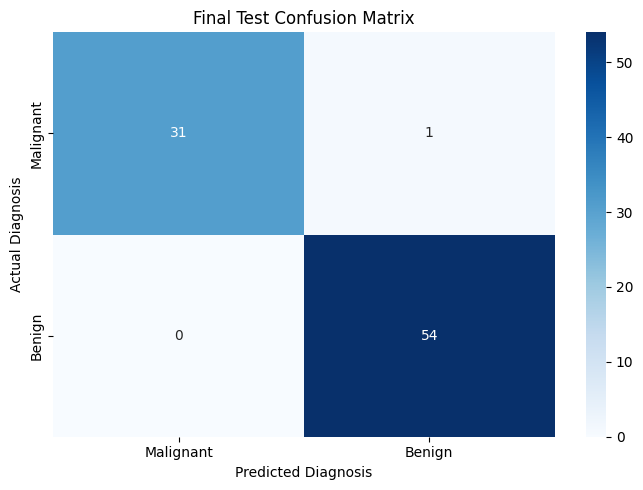

In [48]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Final Test Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()


Of the 86 observations in the test set, 85 were classified correctly. The model correctly identified **31 of 32 malignant observations** and **all 54 benign observations**. One malignant observation was incorrectly classified as benign.


## 13. ROC Analysis


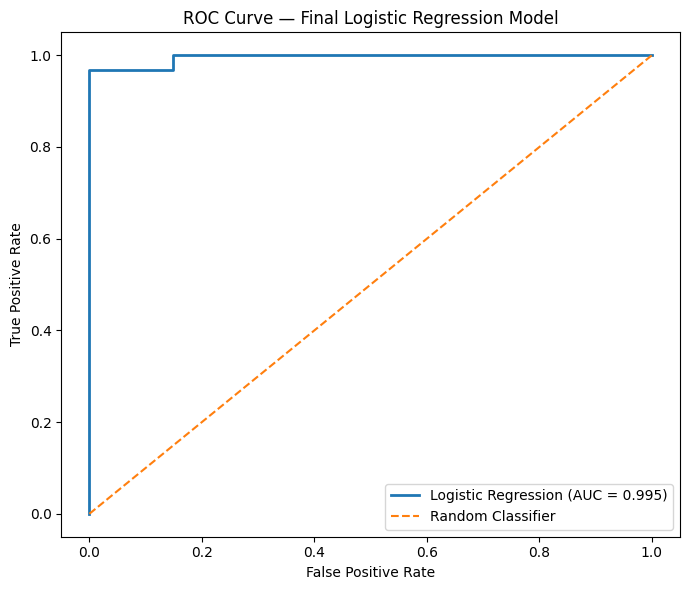

In [49]:
y_test_malignant = (y_test == 0).astype(int)

fpr, tpr, thresholds = roc_curve(y_test_malignant, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Logistic Regression Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


The final model achieved an ROC-AUC of approximately **0.995**, indicating excellent discrimination between malignant and benign observations within the held-out test dataset.


## 14. Model Interpretation

Because the target is encoded as **0 = malignant** and **1 = benign**, negative Logistic Regression coefficients shift predictions toward the malignant class, while positive coefficients shift predictions toward the benign class.

Coefficient magnitude indicates the strength of each feature's contribution on the standardized scale. These coefficients describe associations within the fitted model and should not be interpreted as causal relationships.


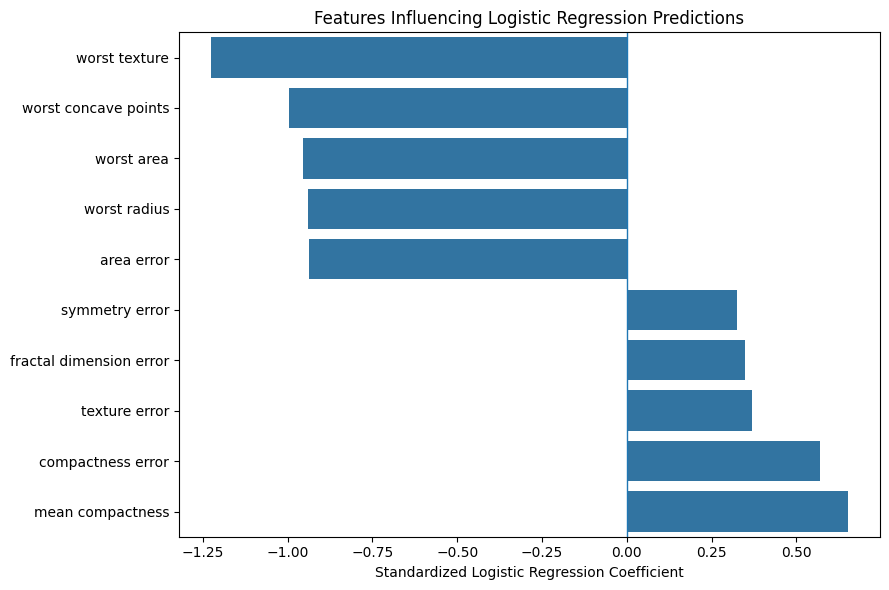

In [50]:
logistic_model = final_model.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coef_sorted = coef_df.sort_values("Coefficient")

malignant_features = coef_sorted.head(5)
benign_features = coef_sorted.tail(5)
top_coefficients = pd.concat([malignant_features, benign_features])

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.axvline(x=0, linewidth=1)
plt.title("Features Influencing Logistic Regression Predictions")
plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 15. Conclusion

This project developed and evaluated multiple machine-learning models for classifying breast tumors as malignant or benign using the Breast Cancer Wisconsin dataset available through scikit-learn.

Logistic Regression was selected as the final model because it demonstrated strong and consistent generalization performance while maintaining a relatively simple and interpretable structure. On the previously unseen test set, the model achieved **98.84% accuracy, 100% malignant-class precision, 96.88% malignant-class recall, a 98.41% malignant-class F1-score, and an ROC-AUC of 0.995**.

Of the 86 test observations, 85 were correctly classified. The model correctly identified 31 of 32 malignant cases and all 54 benign cases.

This project is intended as a machine-learning demonstration and should not be interpreted as a clinically validated diagnostic system.
